In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter("ignore", UserWarning)

## Preparation
- "Houses" data = Google Open Buildings classified as house
  - Filter: remove features with area < 3 sqm
- "Condo" data = From OSM buildings data
  - "residential"
    - w/o name with area > 95th percentile of OSM "house"
    - w/ name with area > 90 sq m (From quick inspection of data)
  - "condominium", "hotel"
  - Others (not "house","residential","condominium") - *name* contains "residence", "condo", "tower"
    - NULL, apartments, residential
    - NOT commercial, office, retail

In [2]:
BLDG_AREA_THRESHOLD = 3 # sq m

In [3]:
bldg = gpd.read_file("..//data//ncr//buildings.gpkg", layer="bldg").to_crs(crs="EPSG:32651")
bldg_class = pd.read_csv("..//data//ncr//bldg_class.csv")
bldg = bldg.merge(bldg_class, how="left", on="full_plus_code")

bldg["area"] = bldg.area
bldg = bldg.loc[bldg["area"]>=BLDG_AREA_THRESHOLD].reset_index(drop=True)
bldg['centroid'] = bldg.geometry.centroid
bldg_cent = bldg.set_geometry("centroid")

In [4]:
bldg_osm = gpd.read_file("..//data//ncr//OSM.gpkg", layer="gis_osm_buildings_a_free_1").to_crs(crs="EPSG:32651")
bldg_osm["area"] = bldg_osm.area

HOUSE_95TH_PERC = bldg_osm.loc[bldg_osm["type"]=="house","area"].quantile(0.95)
print("95th percentile of \"house\" area:",HOUSE_95TH_PERC)

def filter_osm(feature):
    if feature.type=="residential":
        if pd.isna(feature["name"]) and (feature["area"] >= HOUSE_95TH_PERC):
            return True
        elif (not pd.isna(feature["name"])) and (feature["area"]>=90):
            return True
        else:
            return False
    elif feature["type"] in ["condominium","hotel"]:
        return True
    elif ((feature["type"]=="apartments") or pd.isna(feature["type"])) and any([(not pd.isna(feature["name"]))and(x in feature["name"].lower()) for x in ["residence","condo","tower"]]):
        return True
    else:
        return False

bldg_osm = bldg_osm.loc[bldg_osm.apply(filter_osm,axis=1)].reset_index(drop=True)
        
bldg_osm['centroid'] = bldg_osm.geometry.centroid
bldg_osm_cent = bldg_osm.set_geometry("centroid")

95th percentile of "house" area: 280.33025994207236


In [5]:
bldg_cent["type"] = bldg_cent["bldg_class"].map({0:"not house",1:"house"})
bldg_cent = bldg_cent[["full_plus_code","area","centroid","type"]].rename(columns={"full_plus_code":"id"})

bldg_osm_cent["type"] = "condo"
bldg_osm_cent = bldg_osm_cent[["osm_id","area","centroid","type"]].rename(columns={"osm_id":"id"})

bldg_all = pd.concat([bldg_cent,bldg_osm_cent]).reset_index(drop=True)

In [6]:
city = gpd.read_file("..//data//ncr//adm_bounds.gpkg", layer="city").to_crs(crs="EPSG:32651")
brgy = gpd.read_file("..//data//ncr//adm_bounds.gpkg", layer="barangay").to_crs(crs="EPSG:32651")
brgy = brgy.loc[~brgy["ADM4_EN"].isin(["Manila North Cemetery","Tutuban Mall (Claimed by Five Barangays of Tondo, Manila)"])].reset_index(drop=True)

In [7]:
def get_pop_per_area(df):
    return df["weight"]*(df["pop"].values[0]/np.sum(df["weight"]))

def compute_brgy_pop(bldg, brgy, city, weight_dict={"house":1,"not house":0,"condo":50}):
    
    bldg["weight"] = bldg["type"].map(weight_dict)
    
    bldg_det = bldg.sjoin(city[["ADM3_EN","ADM3_PCODE","geometry","pop"]],how="left",predicate="within")\
            .drop(columns=["index_right"])\
            .sjoin(brgy[["ADM4_EN","ADM4_PCODE","ADM3_EN","geometry"]],how="left",predicate="within")\
            .drop(columns=["index_right"])
    
    bldg_det["pop_est"] = bldg_det.groupby("ADM3_PCODE",as_index=False).apply(get_pop_per_area)
    
    brgy_fin = brgy[["ADM4_PCODE","pop"]].merge(bldg_det[["ADM4_PCODE","pop_est"]].groupby("ADM4_PCODE",as_index=False).sum(),how="left",on="ADM4_PCODE")
    brgy_fin.loc[pd.isna(brgy_fin.pop_est),"pop_est"] = 0
    
    return brgy_fin

In [8]:
result_list = []
W_HOUSE = 1
for W_NHOUSE in [0,0.5,1]:
    for W_CONDO in range(0,70+1,5):
        weight_dict = {"house":W_HOUSE,"not house":W_NHOUSE,"condo":W_CONDO}
        result_list.append({**weight_dict, "result":compute_brgy_pop(bldg_all,brgy,city,weight_dict=weight_dict)})

In [9]:
def rmse(arr1,arr2):
    return np.sqrt(np.mean((arr1-arr2)**2))
def mae(arr1,arr2):
    return np.mean(np.abs(arr1-arr2))

result_error_list = []
for x in result_list:
    result_error_list.append({"house":x["house"], "not house":x["not house"], "condo":x["condo"],
                             "rmse":rmse(x["result"]["pop"],x["result"]["pop_est"]),
                             "mae":mae(x["result"]["pop"],x["result"]["pop_est"])})

result_df = pd.DataFrame(result_error_list)

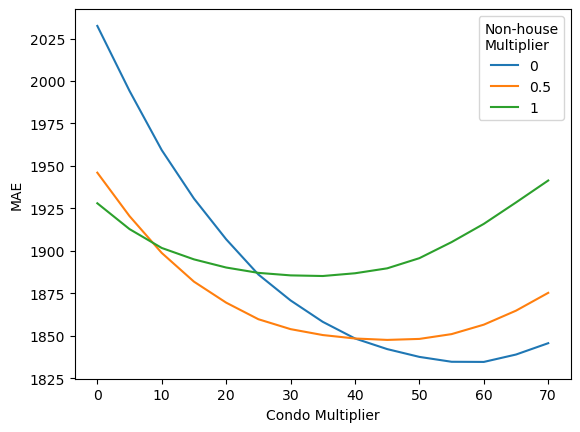

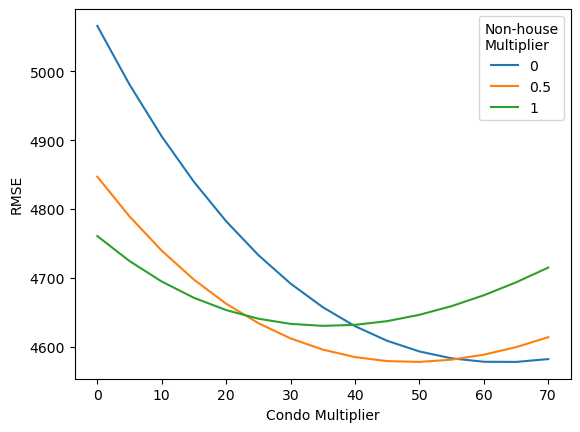

In [10]:
for i in [0,0.5,1]:
    plt.plot(result_df.loc[result_df["not house"]==i,"condo"],result_df.loc[result_df["not house"]==i,"mae"],label=f"{i}")
plt.legend(title="Non-house\nMultiplier")
plt.ylabel("MAE")
plt.xlabel("Condo Multiplier")
plt.show()

for i in [0,0.5,1]:
    plt.plot(result_df.loc[result_df["not house"]==i,"condo"],result_df.loc[result_df["not house"]==i,"rmse"],label=f"{i}")
plt.legend(title="Non-house\nMultiplier")
plt.ylabel("RMSE")
plt.xlabel("Condo Multiplier")
plt.show()

In [11]:
result_df.loc[result_df["rmse"]==result_df["rmse"].min()]

,house,not house,condo,rmse,mae
13,1,0.0,65,4577.892031,1838.974813


In [12]:
result_df.loc[result_df["mae"]==result_df["mae"].min()]

,house,not house,condo,rmse,mae
12,1,0.0,60,4578.136228,1834.623285


In [17]:
print(f"Error metrics when using the weights: House = 1, Non-house = 0, Condo = 60")
print(f"RMSE: {result_df.loc[result_df["mae"]==result_df["mae"].min(),"rmse"].values[0]:.2f}")
print(f"MAE: {result_df.loc[result_df["mae"]==result_df["mae"].min(),"mae"].values[0]:.2f}")

Error metrics when using the weights: House = 1, Non-house = 0, Condo = 60
RMSE: 4578.14
MAE: 1834.62


For context, these are the error metrics for the previous methods:

Root Mean Square Error<br>
Land area-based:		 16232<br>
Building-based:			 8884<br>
Building-based (filtered):	 7438<br>

Mean Absolute Error<br>
Land area-based:		 4516<br>
Building-based:			 3504<br>
Building-based (filtered):	 2929<br>

In [14]:
brgy_best = [x["result"] for x in result_list if x["condo"]==60 and x["not house"]==0][0]

brgy_fin = brgy.merge(brgy_best[["ADM4_PCODE","pop_est"]],how="left",on="ADM4_PCODE")
brgy_fin.loc[pd.isna(brgy_fin.pop_est),"pop_est"] = 0

brgy_fin.to_file("..//data//ncr//brgy_pop_estimates.gpkg",driver="GPKG",layer="building_based_count")
brgy_fin[["ADM4_EN","ADM3_EN","ADM4_PCODE","pop","pop_est"]].to_csv("..//pop_estimates//ncr_building_based_count.csv",index=False)